In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df=pd.read_csv("Loan-Approval-Prediction.csv")
print(df)

      Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0         NaN           

In [30]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [31]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [32]:
print(df["Dependents"])

0       0
1       1
2       0
3       0
4       0
       ..
609     0
610    3+
611     1
612     2
613     0
Name: Dependents, Length: 614, dtype: object


In [33]:
df["Dependents"]=df["Dependents"].replace("3+","3")

In [34]:
print(df["Dependents"])

0      0
1      1
2      0
3      0
4      0
      ..
609    0
610    3
611    1
612    2
613    0
Name: Dependents, Length: 614, dtype: object


In [35]:
cat_cols=["Gender","Married","Dependents","Self_Employed","Loan_Amount_Term","Credit_History"]

In [36]:
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

In [37]:
num_cols=["LoanAmount","ApplicantIncome","CoapplicantIncome"]

In [38]:
for col in num_cols:
    df[col]=df[col].fillna(df[col].mean())

In [39]:
encode_cols=["Gender","Married","Education","Self_Employed","Property_Area","Dependents","Loan_Status"]

In [40]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [41]:
for col in encode_cols:
    df[col]=le.fit_transform(df[col])

In [42]:
print(df)

      Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0    LP001002       1        0           0          0              0   
1    LP001003       1        1           1          0              0   
2    LP001005       1        1           0          0              1   
3    LP001006       1        1           0          1              0   
4    LP001008       1        0           0          0              0   
..        ...     ...      ...         ...        ...            ...   
609  LP002978       0        0           0          0              0   
610  LP002979       1        1           3          0              0   
611  LP002983       1        1           1          0              0   
612  LP002984       1        1           2          0              0   
613  LP002990       0        0           0          0              1   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0  146.412162           

In [43]:
df=df.drop("Loan_ID",axis=1)
print(df)

     Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        0           0          0              0             5849   
1         1        1           1          0              0             4583   
2         1        1           0          0              1             3000   
3         1        1           0          1              0             2583   
4         1        0           0          0              0             6000   
..      ...      ...         ...        ...            ...              ...   
609       0        0           0          0              0             2900   
610       1        1           3          0              0             4106   
611       1        1           1          0              0             8072   
612       1        1           2          0              0             7583   
613       0        0           0          0              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Ter

In [44]:
x=df.drop("Loan_Status",axis=1)
y=df["Loan_Status"]

In [45]:
from sklearn.model_selection import train_test_split
feature_train,feature_test,target_train,target_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [46]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
model=DecisionTreeClassifier(criterion="gini",random_state=42)
model.fit(x,y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(feature_test)

In [48]:
print("Accuracy:",accuracy_score(target_test,y_pred)*100)

Accuracy: 100.0


<function matplotlib.pyplot.show(close=None, block=None)>

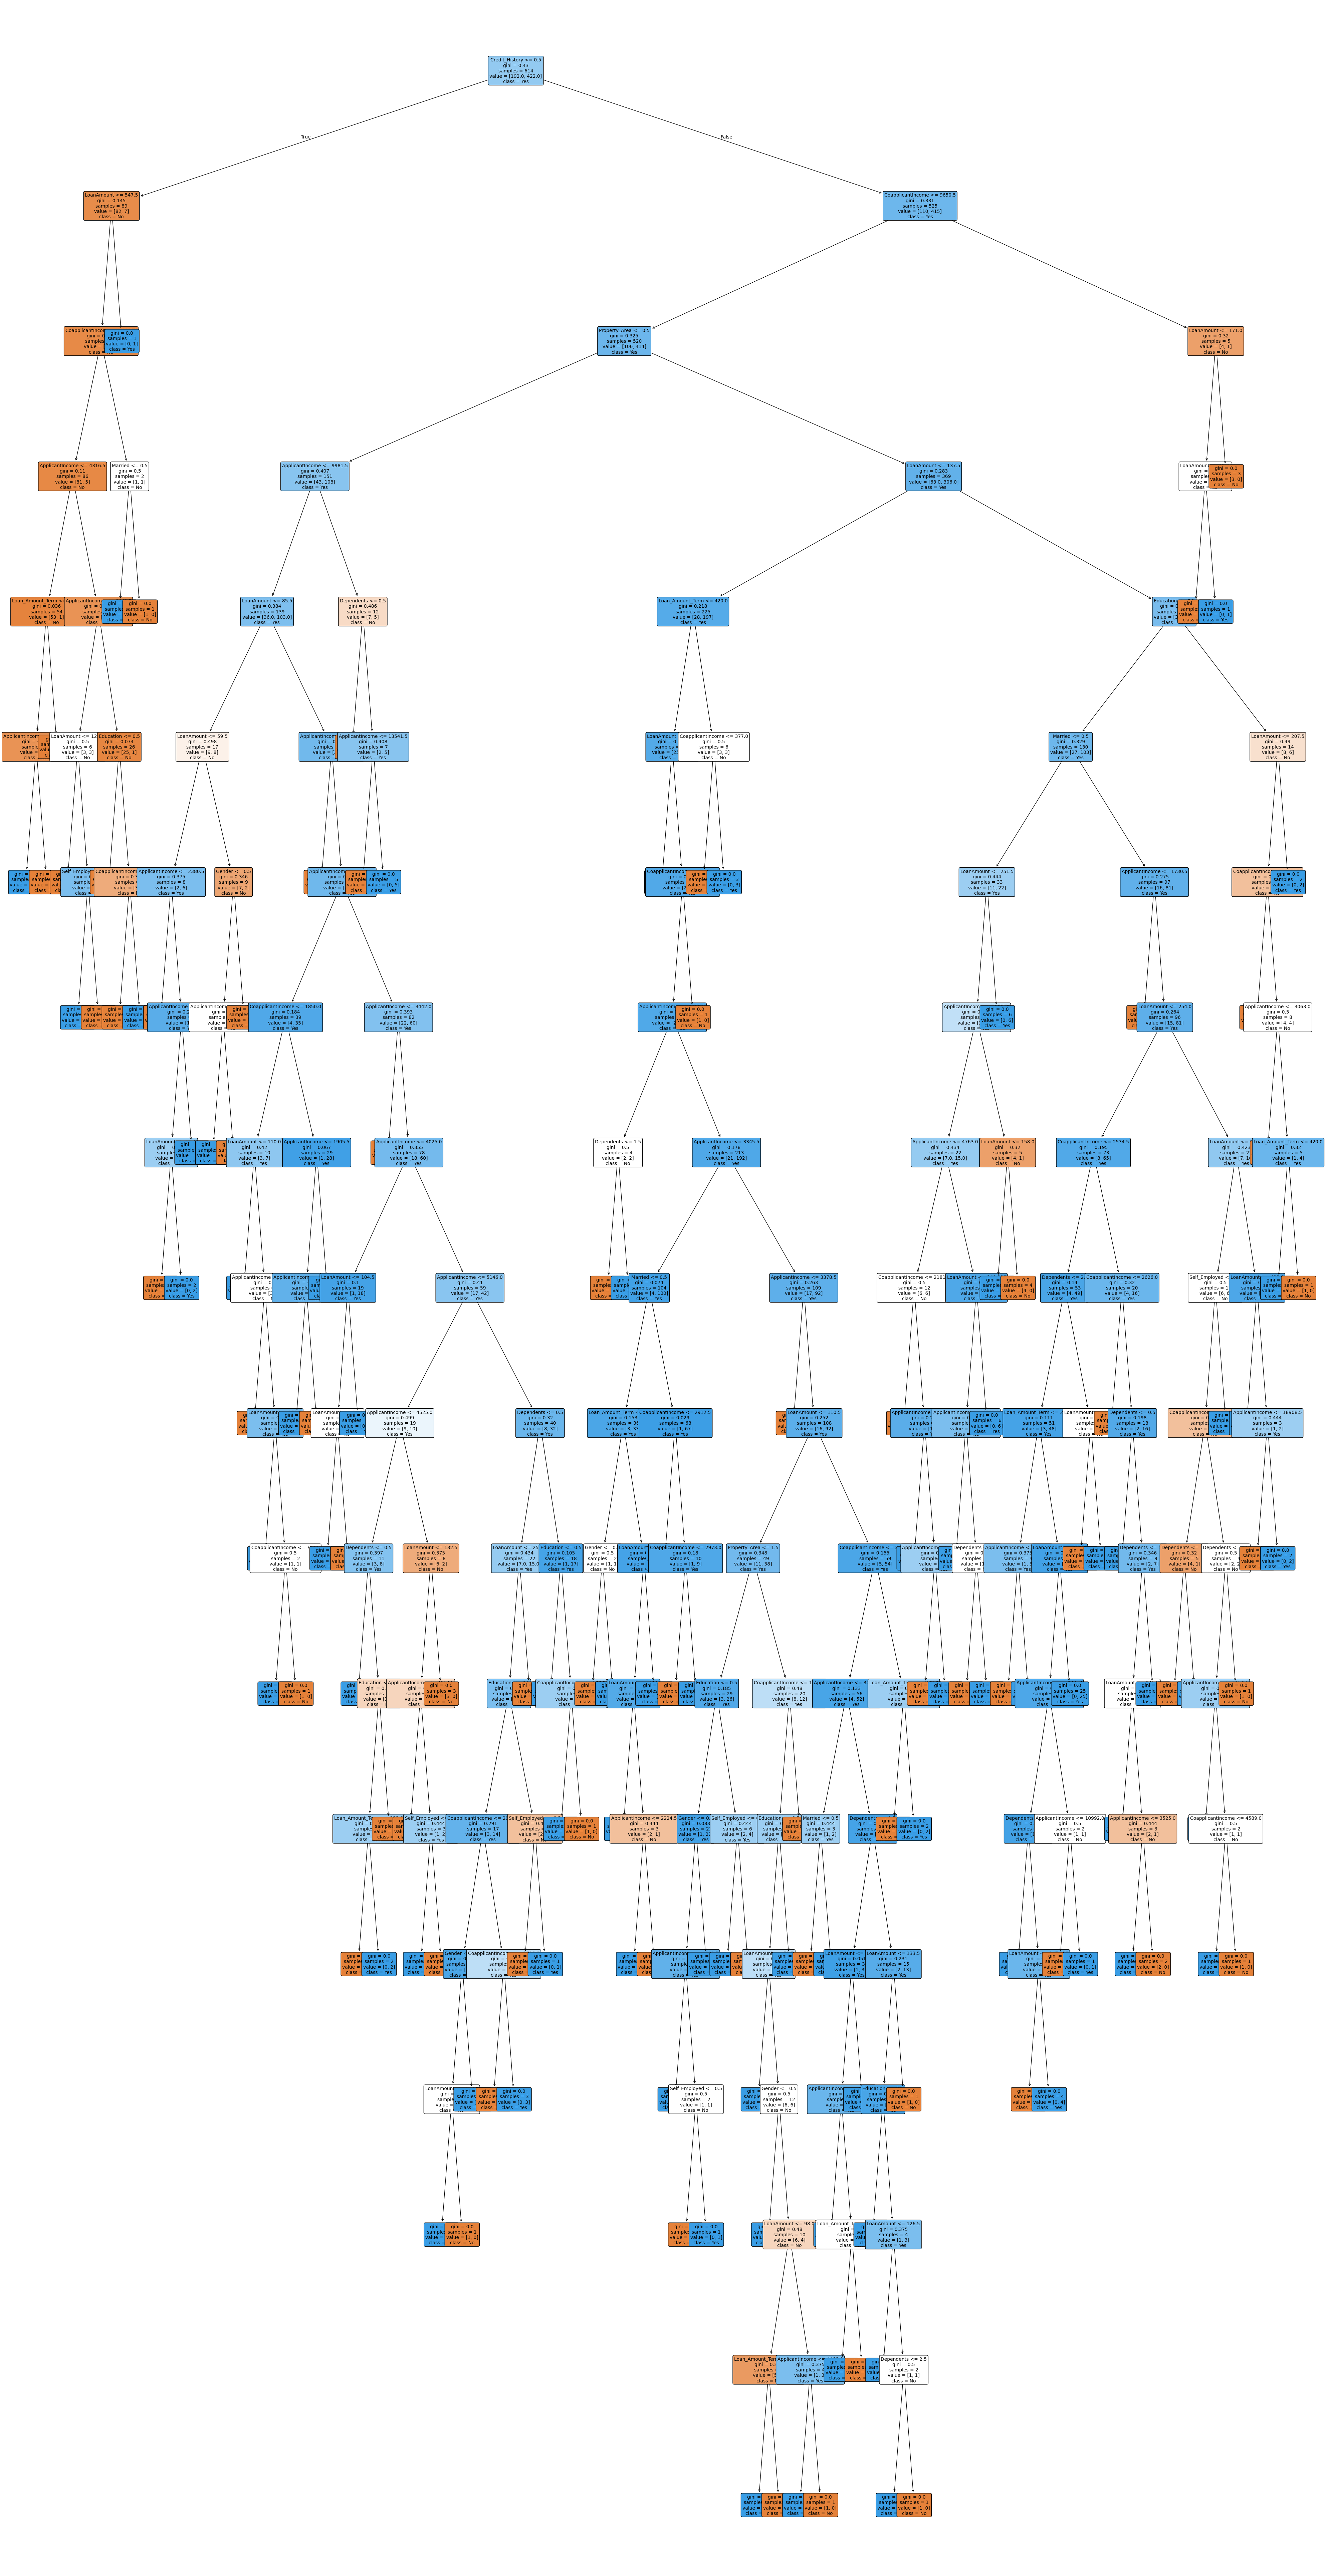

In [50]:
import matplotlib.pyplot as plt
plt.figure(figsize=(50,100))
plot_tree(model,feature_names=x.columns,class_names=["No","Yes"],filled=True,impurity=True,rounded=True,fontsize=10)
plt.show

In [52]:
print(df)

     Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        0           0          0              0             5849   
1         1        1           1          0              0             4583   
2         1        1           0          0              1             3000   
3         1        1           0          1              0             2583   
4         1        0           0          0              0             6000   
..      ...      ...         ...        ...            ...              ...   
609       0        0           0          0              0             2900   
610       1        1           3          0              0             4106   
611       1        1           1          0              0             8072   
612       1        1           2          0              0             7583   
613       0        0           0          0              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Ter